In [2]:

import numpy as np

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter
from scipy.ndimage import gaussian_laplace


from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def wavelet_transform(map_data, scales):
    """Compute Mexican Hat (Laplacian of Gaussian) wavelet transform at multiple scales."""
    wavelet_maps = []
    for sigma_deg in scales:
        # convert degrees to pixels
        pix_scale = np.mean(np.abs(wcs.wcs.cdelt))  # deg/pixel
        sigma_pix = sigma_deg / pix_scale
        
        # Laplacian of Gaussian
        w = -gaussian_laplace(map_data, sigma=sigma_pix) * (sigma_pix**2)
        wavelet_maps.append(w)
    return wavelet_maps

def robust_noise(w):
    """Estimate noise using MAD (robust against sources)."""
    return 1.4826 * np.median(np.abs(w - np.median(w)))

def threshold_maps(wavelet_maps, nsigma=4):
    """Threshold wavelet maps and return boolean masks."""
    masks = []
    for w in wavelet_maps:
        noise = robust_noise(w)
        mask = w > nsigma * noise
        masks.append(mask)
    return masks
def gal_to_cel(l, b):
    c = SkyCoord(l=l*u.degree, b=b*u.degree, frame='galactic')
    return c.icrs.ra.degree, c.icrs.dec.degree

ROI center in Celestial Coordintes = 230, 28
Loading Celestial Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---MOL' 'DEC--MOL' 
CRVAL : 230.0 28.0 
CRPIX : 1800.0 1800.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00277777777777777 0.002777777777777778 
NAXIS : 3600  3600
Fits File loaded
Degrees per pixel: 0.002777777777777778 
Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (1681, 2136)
Peak intensity sky location: <SkyCoord (ICRS): (ra, dec) in deg
    (228.82564385, 27.69989336)>
Peak intensity value: 33.67956430348725


(135.27576445124518, -0.9494740089444768)

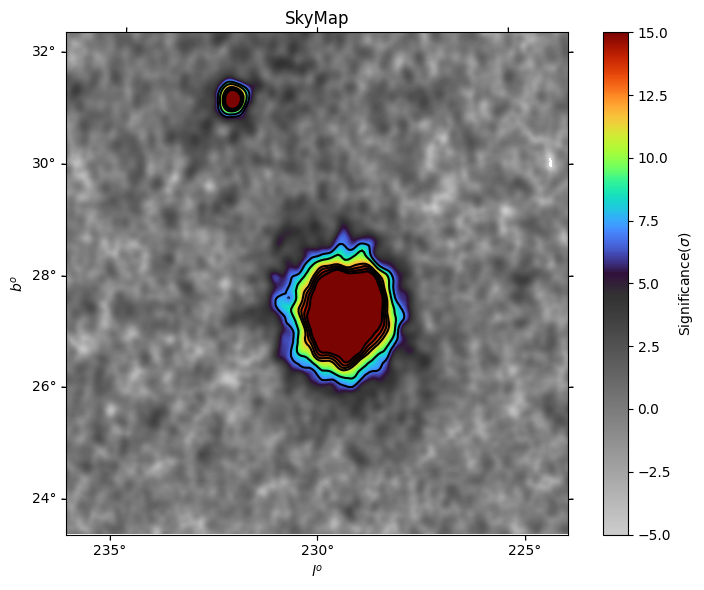

In [60]:
filename ='/Users/rishi/Documents/Analysis/data/map.fits'
filename = '/Users/rishi/Documents/Analysis/AstroImageDetection/map.fits'
x = 230
y = 28
xlength =  10
ylength = 10
coord_sys = 'C' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=5, vmin=-5, vmax=15, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)
gal_to_cel(x, y)

ROI center in Galactic Coordintes = 80, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 80.0 0.0 
CRPIX : 900.0 900.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 1800  1800
Fits File loaded
Degrees per pixel: 0.005555555555555556 
Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (969, 1673)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (75.69967339, 0.38882118)>
Peak intensity value: 60.52751909874575


(308.97121783181626, 40.66361040005763)

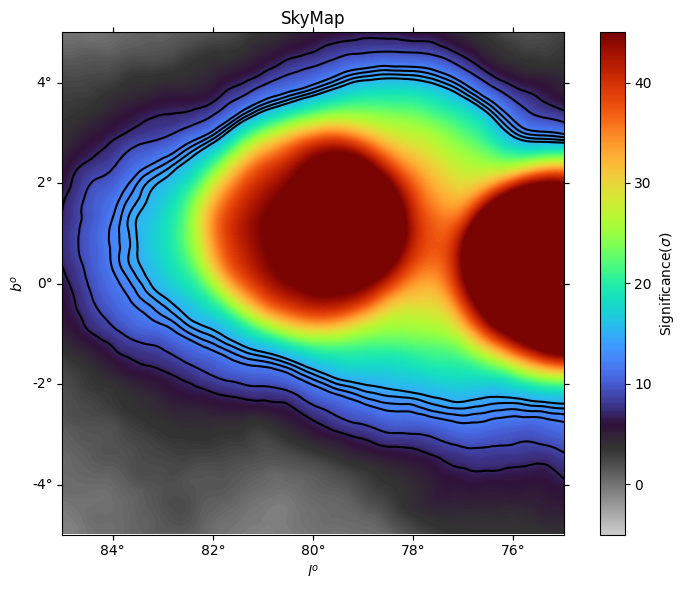

In [148]:
filename ='/Users/rishi/Documents/Analysis/data/map.fits'
filename ='/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext2.0.fits.gz'
x = 80
y = 0
xlength =  5
ylength = 5
coord_sys = 'G' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=5, vmin=-5, vmax=45, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)
gal_to_cel(x, y)

In [149]:
scales = [0.1,0.2, 0.3, 0.5, 0.7, 1.0]
# image = array
# norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
wavelet_maps = wavelet_transform(array, scales)
masks = threshold_maps(wavelet_maps, nsigma=4)

In [150]:
from scipy.ndimage import gaussian_laplace, label
all_seeds = []
min_distance_pix = 1   
for i, mask in enumerate(masks):
    # label connected components
    labeled, nobj = label(mask)
    
    for j in range(1, nobj+1):
        region = (labeled == j)
        # centroid in pixel coordinates
        y, x = np.argwhere(region).mean(axis=0)
        
        # find local maximum inside region (optional refinement)
        coords = peak_local_max(wavelet_maps[i] * region, min_distance=min_distance_pix)
        if len(coords) > 0:
            y_peak, x_peak = coords[0]
        else:
            y_peak, x_peak = y, x
        
        # convert to RA/Dec
        ra, dec = wcs.wcs_pix2world(x_peak, y_peak, 0)
        
        # save seed info: RA, Dec, preferred scale
        all_seeds.append({
            "ra": ra,
            "dec": dec,
            "scale_deg": scales[i]
        })

# -------------------------------
# OUTPUT SEED LIST
# -------------------------------

print("Detected source seeds:")
for s in all_seeds:
    print(f"RA={s['ra']:.4f} deg, Dec={s['dec']:.4f} deg, scale={s['scale_deg']:.2f}°")


Detected source seeds:
RA=75.7926 deg, Dec=1.8109 deg, scale=0.10°
RA=78.4832 deg, Dec=0.9500 deg, scale=0.10°
RA=80.9222 deg, Dec=-0.4722 deg, scale=0.10°
RA=81.6778 deg, Dec=0.2111 deg, scale=0.10°
RA=81.9003 deg, Dec=1.1944 deg, scale=0.10°
RA=75.7213 deg, Dec=1.1831 deg, scale=0.10°
RA=81.2507 deg, Dec=2.2279 deg, scale=0.10°
RA=75.6926 deg, Dec=1.7886 deg, scale=0.20°
RA=79.2551 deg, Dec=2.4224 deg, scale=0.20°
RA=81.6667 deg, Dec=0.3000 deg, scale=0.20°
RA=81.1730 deg, Dec=2.3335 deg, scale=0.20°
RA=75.7540 deg, Dec=1.6609 deg, scale=0.30°
RA=79.4107 deg, Dec=2.4280 deg, scale=0.30°
RA=75.9768 deg, Dec=1.2554 deg, scale=0.50°
RA=78.9109 deg, Dec=1.4334 deg, scale=0.50°
RA=75.7390 deg, Dec=0.2821 deg, scale=0.70°
RA=79.2331 deg, Dec=1.6389 deg, scale=0.70°
RA=75.6419 deg, Dec=0.2581 deg, scale=1.00°
RA=79.7111 deg, Dec=1.3000 deg, scale=1.00°


In [151]:
def plot_wavelet_maps(map_data, wavelet_maps, masks, scales, wcs, all_seeds):
    """
    Plots original map, wavelet maps, and overlay clusters/seeds.
    
    Parameters:
        map_data: 2D numpy array of original map
        wavelet_maps: list of wavelet-transformed maps at different scales
        masks: list of boolean masks from thresholding
        scales: list of scales (degrees) corresponding to wavelet_maps
        wcs: astropy WCS object
        all_seeds: list of dicts with RA/Dec and scale for detected seeds
    """
    n_scales = len(scales)
    fig, axes = plt.subplots(1, n_scales + 1, figsize=(4*(n_scales+1),4), subplot_kw={'projection': wcs})
    
    # Original map
    ax0 = axes[0]
    im0 = ax0.imshow(map_data, origin='lower', cmap='gray')
    ax0.set_title("Original Map")
    plt.colorbar(im0, ax=ax0, orientation='vertical', fraction=0.046)
    
    # Wavelet maps + clusters
    for i, (w_map, mask, scale) in enumerate(zip(wavelet_maps, masks, scales)):
        ax = axes[i+1]
        im = ax.imshow(w_map, origin='lower', cmap='viridis')
        ax.set_title(f"Wavelet σ={scale}°")
        plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046)
        
        # Overlay clusters as contours
        ax.contour(mask, colors='red', linewidths=1)
        
        # Overlay seed positions (for this scale)
        for seed in all_seeds:
            if seed['scale_deg'] == scale:
                x_seed, y_seed = wcs.wcs_world2pix(seed['ra'], seed['dec'], 0)
                c = Circle((x_seed, y_seed), radius=3, edgecolor='yellow', facecolor='none', lw=1.5)
                ax.add_patch(c)
    
    plt.tight_layout()
    plt.show()

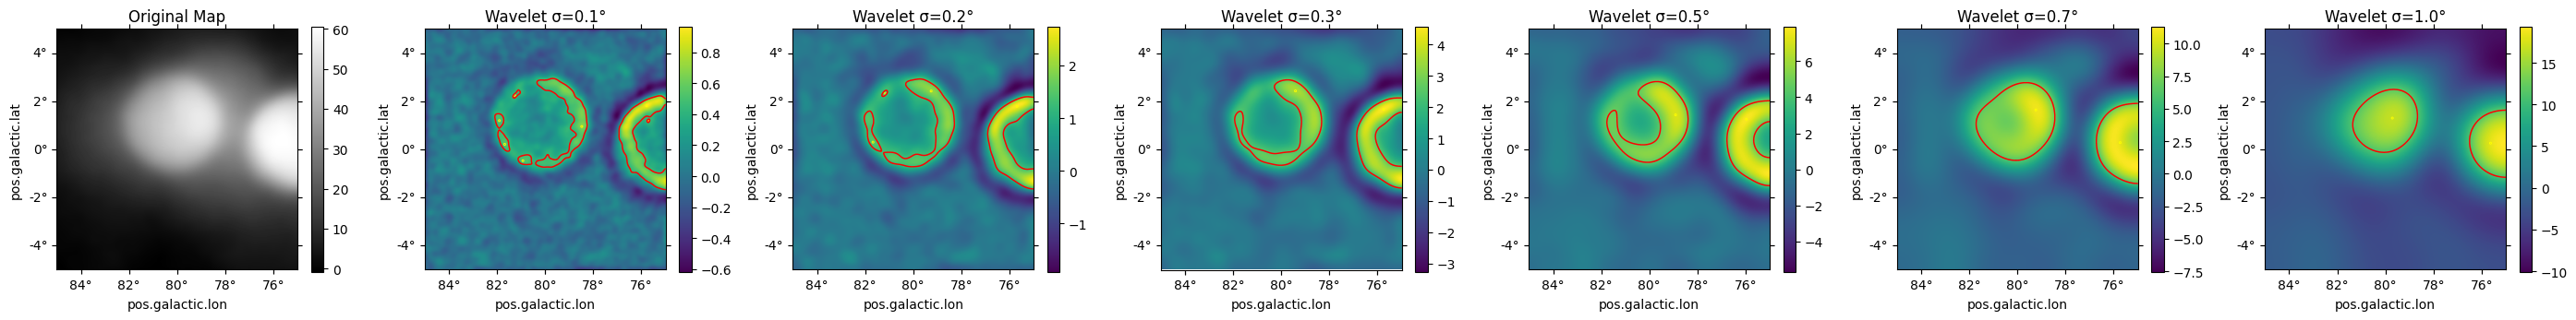

In [152]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

plot_wavelet_maps(array, wavelet_maps, masks, scales, wcs, all_seeds)

In [109]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# Convert seeds to SkyCoord
coords = SkyCoord([s['ra'] for s in all_seeds]*u.deg,
                  [s['dec'] for s in all_seeds]*u.deg)

final_seeds = []
used = np.zeros(len(all_seeds), dtype=bool)
match_radius = 0.3  # degrees, can tune based on HAWC PSF

for i, seed in enumerate(all_seeds):
    if used[i]:
        continue
    # find nearby seeds
    sep = coords[i].separation(coords).deg
    group_idx = np.where(sep < match_radius)[0]
    
    # pick seed with smallest scale (prefer point source)
    best_idx = group_idx[np.argmin([all_seeds[j]['scale_deg'] for j in group_idx])]
    final_seeds.append(all_seeds[best_idx])
    
    # mark all group as used
    used[group_idx] = True

# final_seeds now contains merged seeds with point sources preserved


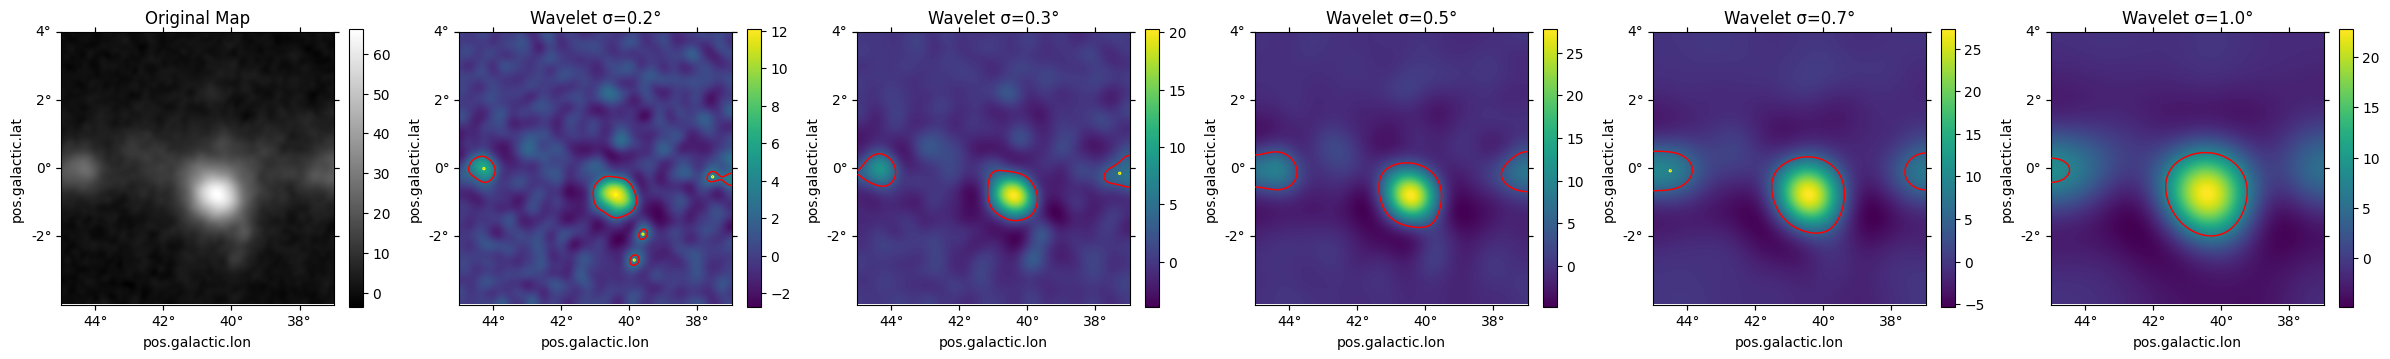

In [110]:
plot_wavelet_maps(array, wavelet_maps, masks, scales, wcs, final_seeds)